# Backend of the streamlit website

### Import libraries

In [2]:
#from datetime import datetime, timedelta
#from dateutil.relativedelta import relativedelta  
#import requests
#import concurrent.futures
#from dateutil.relativedelta import relativedelta
#import matplotlib.pyplot as plt
#import base64
#import numpy as np
#import time
#from lxml import html
#import re
#import json
#from dotenv import load_dotenv

#interact with the internet
import os

#data manipulation
import pandas as pd

# load the external library that is created,  this is the wi_utils.py file
import importlib
import wi_utils
from wi_utils import *
importlib.reload(wi_utils)


<module 'wi_utils' from '/Users/yanvansnippenburg/Documents/NAHSS/wi_app/wi_utils.py'>

In [3]:
print(dir(wi_utils))

['GITHUB_BRANCH', 'GITHUB_REPO', 'GITHUB_TOKEN', 'Rectangle', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'classify_value', 'collect_and_upload_weather_data', 'columns', 'coord_data', 'datetime', 'fetch_and_upload', 'fetch_sugar_price', 'fetch_vietnam_maize_price', 'fetch_vietnam_rice_price', 'filter_cities_by_distance', 'fx_API_KEY', 'gen_graphs_cities_periods', 'get_lon_lat_data', 'get_nasa_power_weather', 'get_past_days_average_by_coords', 'get_vnd_to_usd_rate', 'get_weather', 'haversine_distance', 'html', 'json', 'load_dotenv', 'np', 'os', 'pd', 'plot_forecast', 'plt', 're', 'relativedelta', 'repo', 'repo_url', 'requests', 'save_and_upload_crop_prices', 'save_and_upload_lists', 'search_city', 'text_upload', 'time', 'timedelta', 'upload_csv', 'upload_to_github', 'user', 'viet_coord_data', 'weather_api_key']


## Set selections

In [54]:
selected_cities = ["Hanoi", "Western Region", "Ho Chi Minh City", "Red River Delta"] #Selected cities as start # maybe 7 largest cities?, filtered cities is better

selected_periods = [1, 3, 6]  # in months #other timeframes
selected_crops = ["Rice", "Maize", "Sugarcane"]


### Data set processing for the file filtered_cities.csv


Process a set with interesting and covering places 


In [4]:
coord_data = pd.read_csv("text_data/VN.txt", sep="\t", names=columns, dtype=str)
# Make sure population is numeric
coord_data["population"] = pd.to_numeric(coord_data["population"], errors="coerce")

# Count number of NaNs per row (used for tie-breaking)
coord_data["nan_count"] = coord_data.isna().sum(axis=1)

# Sort by asciiname, then by:
# 1. population (descending, NaNs go last)
# 2. fewest NaNs (ascending)
coord_data_sorted = coord_data.sort_values(
    by=["asciiname", "population", "nan_count"],
    ascending=[True, False, True]
)

# Drop duplicates, keeping the "best" row per asciiname
coord_data = coord_data_sorted.drop_duplicates(subset="asciiname", keep="first")

# Drop the helper column
coord_data = coord_data.drop(columns=["nan_count"])

coord_data[coord_data["asciiname"] == "Ca Mau"] 

,geonameid,name,asciiname,alternatenames,latitude,longitude,feature_class,feature_code,country_code,cc2,admin1_code,admin2_code,admin3_code,admin4_code,population,elevation,dem,timezone,modification_date
26026,1586443,Cà Mau,Ca Mau,"CAH,Ca Mau,Camo,Cu Mau,Cà Mau,Kamao,Kamau,Quan...",9.17682,105.15242,P,PPLA,VN,NaN,77,964,NaN,NaN,226372,NaN,5,Asia/Ho_Chi_Minh,2025-06-20


In [1]:
# prepare cols to load the complete data csv
columns = [
    "geonameid", "name", "asciiname", "alternatenames",
    "latitude", "longitude", "feature_class", "feature_code",
    "country_code", "cc2", "admin1_code", "admin2_code",
    "admin3_code", "admin4_code", "population", "elevation",
    "dem", "timezone", "modification_date"
]

# Load file
coord_data = pd.read_csv("text_data/VN.txt", sep="\t", names=columns, dtype=str)
# Convert lat/lon and population to numeric
coord_data["latitude"] = pd.to_numeric(coord_data["latitude"])
coord_data["longitude"] = pd.to_numeric(coord_data["longitude"])

# Remove the duplicate names
coord_data["population"] = pd.to_numeric(coord_data["population"], errors="coerce")

# Count number of NaNs per row (used for tie-breaking)
coord_data["nan_count"] = coord_data.isna().sum(axis=1)

# Sort by asciiname, then by:
# 1. population (descending, NaNs go last)
# 2. fewest NaNs (ascending)
coord_data_sorted = coord_data.sort_values(
    by=["asciiname", "population", "nan_count"],
    ascending=[True, False, True]
)

# Drop duplicates, keeping the "best" row per asciiname
coord_data = coord_data_sorted.drop_duplicates(subset="asciiname", keep="first")
coord_data = coord_data.drop(columns=["nan_count"])

## End of the preparation of the full dataset
upload_csv(coord_data, filename="Viet_coords.csv") #upload the original coordinates file

# Start the preparation of the set "filtered_cities"
coord_data = coord_data[[
    "name", "asciiname", "alternatenames",
    "latitude", "longitude", "feature_class", "feature_code",
    "population",
    "dem"
]]

# Keep Ho Chi Minh as standard
ho_chi_minh_ascii = "ho chi minh city"

# Get the row for Ho Chi Minh City
hcm_row = coord_data[(coord_data["asciiname"].str.lower() == ho_chi_minh_ascii) & (coord_data["feature_class"] == "P")]

# keep only the sensible values
coord_data["dem"] = pd.to_numeric(coord_data["dem"], errors="coerce")

coord_data = coord_data[
    (coord_data["dem"].notna()) &
    (coord_data["dem"] >= 0) &
    (coord_data["population"].notna()) &
    (coord_data["population"] >= 0) &
    (coord_data["latitude"].notna()) &
    (coord_data["longitude"].notna())
][[
    "name", "asciiname", "alternatenames",
    "latitude", "longitude", "feature_class", "feature_code",
    "population",
    "dem"
]]

# Only keep rural/small places with valid population
coord_data = coord_data[
    (
        (
            (coord_data["feature_class"] == "P") &
            (coord_data["feature_code"].isin(["PPL", "PPLF", "PPLX", "PPLA2"])) &
            (coord_data["population"].notnull()) &
            (coord_data["population"] > 100) &
            (coord_data["population"] < 5000)
        ) |
        (
            (coord_data["feature_class"] == "S") &
            (coord_data["feature_code"].isin(["FRM", "AGR", "ML"]) )
        ) |
        (
            (coord_data["feature_class"] == "L") &
            (coord_data["feature_code"].isin(["AGRC", "FLDI"])) 
        )
        |
        (
            (coord_data["feature_class"] == "A") &
            (coord_data["feature_code"].isin(["ADM1", "ADM2"])) &
            (coord_data["population"] > 100) &
            (coord_data["population"] < 200000)
        )
    )
]
coord_data.drop(columns=["feature_class", "feature_code"], inplace=True)

#Apply clustering heuristic, with radius set to 30 km
print(len(coord_data))
filtered_cities = filter_cities_by_distance(coord_data, min_distance_km=2)

# Add it Ho Chi Minh to filtered_cities (only if it's not already included)
if not hcm_row.empty and hcm_row["asciiname"].values[0] not in filtered_cities["asciiname"].values:
    filtered_cities = pd.concat([filtered_cities, hcm_row], ignore_index=True)

upload_csv(filtered_cities)

NameError: name 'pd' is not defined

In [193]:
len(filtered_cities) #This number is smaller than the total dataset, confirming the validity 

216

Display the map of Vietnam with the cities we deem interesting


In [ ]:
import folium
from IPython.display import display

def plot_places_on_vietnam_map(df):
    # Calculate bounds: [[min_lat, min_lon], [max_lat, max_lon]]
    min_lat, max_lat = df["latitude"].min(), df["latitude"].max()
    min_lon, max_lon = df["longitude"].min(), df["longitude"].max()
    bounds = [[min_lat, min_lon], [max_lat, max_lon]]

    # Initialize map at the center of bounds (optional, just to set a starting point)
    center_lat = (min_lat + max_lat) / 2
    center_lon = (min_lon + max_lon) / 2
    m = folium.Map(location=[center_lat, center_lon], zoom_start=6)

    # Add markers
    for _, row in df.iterrows():
        folium.Marker(
            location=[row["latitude"], row["longitude"]],
            popup=row["name"],
            icon=folium.Icon(color="green", icon="info-sign")
        ).add_to(m)

    # Fit map to bounds to show all markers
    m.fit_bounds(bounds)

    display(m)

plot_places_on_vietnam_map(filtered_cities)

Upload the datasets to Github

In [175]:
save_and_upload_lists({
            "selected_cities": selected_cities, #for test.py
            "selected_periods": selected_periods, 
            "selected_crops": selected_crops,
            "filtered_cities": filtered_cities["name"].tolist(), # for test_2.py 
        }, folder="scalability")

Successfully uploaded scalability/selected_cities.txt
Successfully uploaded scalability/selected_periods.txt
Successfully uploaded scalability/selected_crops.txt
Successfully uploaded scalability/filtered_cities.txt


### Use the search_city function, enter a place, then the closest place to the one in the set will be used

In [486]:
nearest_city, message = search_city("Hanoi", filtered_cities=filtered_cities, coord_threshold=0.2)
message

"The closest city with data is 'Liên Quan', which is approximately 20.00 km from 'hanoi'."

In [ ]:
x = [1,2,5,10,15,20,25,30]
y = [85, 83, 72, 63, 58, 53, 50, 46]



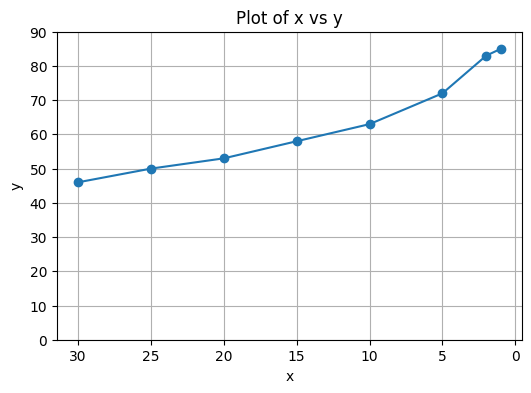

In [113]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(x, y, marker='o')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Plot of x vs y')
plt.grid(True)
plt.gca().invert_xaxis()  # Reverse the x-axis direction
plt.ylim(0, 90)  # Set y-axis from 0 to 90
plt.show()

# Upload Information Data


## Temperature Data

Upload the daily weather info for the test.py file

In [176]:
collect_and_upload_weather_data(selected_cities, folder="climate_data")

Successfully uploaded climate_data/weather_data_today.csv


'https://raw.githubusercontent.com/vanSnip/wi_app/main/climate_data/weather_data_today.csv'

Upload the daily weather info for the test_2.py file

In [177]:
#create climate_data_2 folder   
os.makedirs("climate_data_2", exist_ok=True)
collect_and_upload_weather_data(filtered_cities["name"].tolist(), folder="climate_data_2")

Successfully uploaded climate_data_2/weather_data_today.csv


'https://raw.githubusercontent.com/vanSnip/wi_app/main/climate_data_2/weather_data_today.csv'

Give previous weather for selection (currently to costly)

In [178]:
#gen_graphs_cities_periods(selected_cities, selected_periods)
#gen_graphs_cities_periods(filtered_cities["name"].tolist(), selected_periods, folder="scalability")

## Crop Prices

Initialise vars for local inspection


In [503]:
vnd_usd_rate = get_vnd_to_usd_rate()
rice_price = fetch_vietnam_rice_price() #monthly
sugar_price = fetch_sugar_price() # this one is worldwide, not Vietnam specific # daily
maize_price = fetch_vietnam_maize_price()
print(f"VND to USD exchange rate: {vnd_usd_rate} vnd/usd")
print(f"Rice price: {rice_price} USD/kg")
print(f"Sugar price: {sugar_price} USD/kg")
print(f"Maize price: {maize_price} USD/kg")

VND to USD exchange rate: 26055.8844 vnd/usd
Rice price: 0.37716000000000005 USD/kg
Sugar price: 0.36103738968 USD/kg
Maize price: 0.6609543447314343 USD/kg


Upload the most recent prices

In [504]:
CropPrices = {
    "Rice": round(fetch_vietnam_rice_price(), 2),
    "Maize": round(fetch_vietnam_maize_price(), 2),
    "Sugarcane": round(fetch_sugar_price(), 2)
}

save_and_upload_crop_prices(CropPrices, selected_crops, folder="price_data")

Successfully uploaded price_data/crop_prices.csv


## Weather Advice per crop and scenario

advice under avg rain

In [550]:
text_upload(
    "rain0",
    "weather",
    "It is raining less than average, try to water the crops manually or use irrigation systems.",
    )

Successfully uploaded texts/advice_weather_rain0.txt


advice avg rain


In [551]:
text_upload(
    "rain1",
    "weather",
    "it is raining as average as the last 10 days, no need to change your actions."
    )

Successfully uploaded texts/advice_weather_rain1.txt


advice above avg rain 

In [552]:
text_upload(
    "rain2",
    "weather",
    "It is raining more than average, you can stop watering the crops manually or use irrigation systems less frequently."
    )

Successfully uploaded texts/advice_weather_rain2.txt


#### Weather wind advice

advice for under avg wind

In [553]:
text_upload(
    "wind0",
    "weather",
    "`The wind is less than average, no actions needed`",
    )

Successfully uploaded texts/advice_weather_wind0.txt


advice for avg wind


In [554]:
text_upload(
    "wind1",
    "weather",
    "It wind is as average, no need to change your actions."
    )

Successfully uploaded texts/advice_weather_wind1.txt


advice for above avg wind

In [555]:
text_upload(
    "wind2",
    "weather",
    "The wind is as average, consider protecting young or tall crops with windbreaks and avoid spraying during windy conditions."
)

Successfully uploaded texts/advice_weather_wind2.txt


#### Weather temp advice

advice for under avg weather temp

In [556]:
text_upload(
    "temp0",
    "weather",
    "It is colder than average, consider using greenhouses or other heating methods to protect crops.",
    )

Successfully uploaded texts/advice_weather_temp0.txt


advice for avg weather temp

In [557]:
text_upload(
    "temp1",
    "weather",
    "It is as warm as average, no need to change your actions.",
    )

Successfully uploaded texts/advice_weather_temp1.txt


advice for above avg weather temp

In [558]:
text_upload(
    "temp2",
    "weather",
    "It is warmer than average, consider using shade nets or other cooling methods to protect crops.",
    )

Successfully uploaded texts/advice_weather_temp2.txt


## Upload static Data

### Upload the Novel Farming Techniques

Do the text of step by step, #send a picture if not data saving, for illustrations. 


In [3]:
text_upload(
    "SBS",
    "guide",
    "Welcome to the information of a step by step guide for conservation agriculture \n"
    "\n"
    "Step 1: Field Lay Out \n"
    "All crop rows should be 75 cm apart from each other, and the distance between the crops in each row should be 75 cm.\n"
    "If the soil is dry, increase the row spacing to 90 cm and crop spacing to 90 cm.\n"
    "To do this effectively, use a piece of rope for consistent measurements. \n"
    "\nStep 2: The Baisins "
    "\n"
    "The baisins should be 15 cm long, 8 cm wide and 10 cm deep. \n"
    "\n Step 3: Fertiliser and Compost \n"
    "The fertiliser should be put in first, under the soil, use a 2 caps of a soda bottle of fertiliser per baisin. \n"
    "Then add compost, use a 2 hands of compost per baisin. \n"
) 
'''
calculations for a more efficient grid structure
(75**2-37.5**2)**.5 = 64.9519052838329

(90**2-45**2)**.5 = 77.94228634059948
'''

Successfully uploaded texts/advice_guide_sbs.txt


'\ncalculations for a more efficient grid structure\n(75**2-37.5**2)**.5 = 64.9519052838329\n\n(90**2-45**2)**.5 = 77.94228634059948\n'

The three practices

In [4]:
text_upload(
    "3PGAP", 
    "guide", 
    "Welcome to the information page of the three main principles of conservation agriculture: \n"
    "\n" 
    "Principle 1: Minimal soil disturbance \n"
    "The soil should not be disturbed with a plough or something similar, as this can damage the soil structure and lead to erosion. \n"
    "The advantages are: \n"
    "Protection against wind and erosion: \n"
    "Improve the quality of the organic matter in the soil: \n"
    "Decrease the costs in the long term: \n"
    "Improve the water absorption and retention. \n"
    "The fertiliser becomes more effective. \n"
    "\n"
    "Principle 2: Permanent soil cover with organic matters. \n"
    "This means that the soil should covered with organic matter, such as crop residues or cover crops, to protect it from erosion and improve its fertility. \n"
    "Advantages: \n"
    "Protection from erosion from wind and water: \n"
    "It recycles the use of nutrients: \n"
    "Suppresses the growth of weeds (unwanted plants): \n"
    "Improves accumalation of organic matter, further enhancing the effect: \n"
    "\n"
    "Principle 3: Crop rotation and intercropping \n"
    "This means that different crops are grown in the same field after each other, to improve soil fertility and reduce pests and diseases. \n"
    "The effect is the best if the crops are different families, such as legumes and cereals. \n"
    "Advantages: \n"
    "Improves the soil fertility and structure \n"
    "Reduces the risk of pests and diseases \n"
    "Increases the water use \n"
    "\n"
    "Disclaimer: These materials have been based on the materials commissioned by FAO Lesotho and the Ministry of Agriculture and Food Security with financial support " \
    "from the European Commission Humaitarian Aid and Civil Protection Directorate (ECHO) and OFDA in 2012. These materials were developed in coordination with, and endorsed by, " \
    "the Lesotho Conservation Agriculture National Task Force (LCANTF). Furthermore, the information is processed with the help of a LLM Github Copilot, which is not a human expert. " \

    )

Successfully uploaded texts/advice_guide_3pgap.txt


Introduction to conservation agriculture main menu


In [5]:
text_upload(
    "CA", 
    "guide", 
    "Welcome to the information page of conservation agriculture: \n"
    "\n"
    "Conservation agriculture is a farming technique that aims to improve soil health and productivity while reducing environmental impact. This is important as the current climate is changing rapidly. "
    "\n Conservation agriculture helps adapting to unpredicatble climate and unpredictable rainfall, it provides more food security. \n"
    "\n"
    "\n The consequences of climate change are: \n"
    "1. Extreme temperatures \n"
    "2. Unpredictable rainfall \n"
    "3. Droughts \n"
    "4. Floods \n"
    "\n"
    "Besides conservation agriculture, there are other methods to adapt to climate change, such as water tanks to always have water available, irrigation systems to efficiently water the crops, "
    "and crop diversification. \n"
    "\n"
    "The three main principles of conservation agriculture are shown below. Click the buttons for more information about the specific iinformation.  \n"
    "1. Minimal soil disturbance \n"
    "2. Permanent soil cover with organic matters \n"
    "3. Crop rotation and intercropping \n"
    "\n"
    "A step by step guide is available to help you implement conservation agriculture in your farm. \n"
      )

Successfully uploaded texts/advice_guide_ca.txt


Alternative cultivation techniques-aqua rice farming

In [6]:
text_upload(
    "RiceAquaculture",
    "guide",
    "Welcome to the information page of rice–aquaculture systems: \n"
    "\n"
    "Rice aquaculture systems are farming methods that combine rice growing with raising aquatic animals like shrimp or fish. "
    "These systems help farmers adapt to climate change, improve soil health, and increase income. \n"
    "\n"
    "This method is especially useful as the climate becomes more unpredictable, with: \n"
    "1. Salty water during dry seasons \n"
    "2. Unpredictable rainfall \n"
    "3. Flooding and drought \n"
    "\n"
    "There are two main types of rice aquaculture systems used in Vietnam: \n"
    "\n"
    "1. Rice-Shrimp Rotation: \n"
    "- Suitable for areas with seasonal salinity (saltwater). \n"
    "- Shrimp are raised in the dry season when water is salty. \n"
    "- In the rainy season, rainwater cleans the soil and prepares it for rice. \n"
    "- Shrimp waste gives nutrients to the rice. \n"
    "- Rice helps loosen and clean the soil for the next shrimp season. \n"
    "- This system is common in the Mekong Delta. \n"
    "\n"
    "2. Rice–Fish Co-Cultivation: \n"
    "- Rice and fish are grown in the same field. \n"
    "- Helps keep rice yields strong and provides fish for food and extra income. \n"
    "- Supports household food security. \n"
    "- Must be managed carefully to avoid environmental problems. \n"
    "\n"
    "The Vietnamese government is helping farmers with policies to support integrated farming. \n"
    "- Farmers are encouraged to convert low-yield rice fields into rice aquaculture areas. \n"
    "- These systems improve profitability and climate resilience. \n"
    "\n"
    "Below is a simple guide for rice–fish cultivation: \n"
    "\n"
    "Start of the rainy season (May–June): \n"
    "- Transplant rice as soon as the soil is moist. \n"
    "- After 2 weeks, when rice is stable, stock the fish. \n"
    "\n"
    "If heavy rain or flooding is expected: \n"
    "- Wait to plant rice and add fish until water is stable. \n"
    "\n"
    "In dry periods: \n"
    "- Water the rice regularly. \n"
    "- Shade the fish with floating plants. \n"
    "- Reduce fish feeding to prevent water stress. \n"
    "\n"
    "Before a storm or typhoon: \n"
    "- Harvest mature rice and fish early. \n"
    "- Move fish to safer ponds if possible. \n"
    "\n"
)

Successfully uploaded texts/advice_guide_riceaquaculture.txt


### Crop Advice 

#### Cultivation tips

In [7]:
text_upload(
    "Rice",
    "cul", 
    "Welcome to the basic rice farming guide: This guide gives simple steps to help you grow rice successfully. \n"
    "1. Choose Good Seeds \n"
    "- Use clean and healthy seeds. \n"
    "- Get them from trusted sources to ensure strong plants. \n"
    "\n"
    "2. Prepare Your Land \n"
    "- Level your field so water spreads evenly. \n"
    "- Remove weeds and leftover plants from the last season. \n"
    "- Use compost or animal manure to improve the soil. \n"
    "\n"
    "3. Plant at the Right Time \n"
    "- Transplant rice seedlings 20–25 days after sowing. \n"
    "\n"
    "4. Use Water Wisely \n"
    "- Keep water 2–5 cm deep in the field while the rice is growing. \n"
    "\n"
    "5. Use Fertiliser Correctly \n"
    "- Apply fertiliser when rice is growing and when grains start forming. \n"
    "\n"
    "6. Harvest at the Right Time \n"
    "- Harvest when about 85 percent of the grains are yellow. \n"
    "- Do not wait too long—grains may fall to the ground. \n"
    "\n"
    "Tip: If your field has salty water (common in southern Vietnam), use salt-tolerant rice varieties. \n"
    )

Successfully uploaded texts/advice_cul_rice.txt


In [8]:
text_upload(
    "Maize",
    "cul",
    "Welcome to the basic maize farming guide: This guide helps you grow healthy maize plants and improve your harvest. \n"
    "1. Choose Good Seeds \n"
    "- Select high-yield and drought-tolerant maize varieties. \n"
    "- Use certified seeds from trusted suppliers. \n"
    "\n"
    "2. Prepare the Land \n"
    "- Plough the land well and break large soil clumps. \n"
    "- Add compost or manure before planting to enrich the soil. \n"
    "\n"
    "3. Plant at the Right Time \n"
    "- Plant just before or at the start of the rainy season. \n"
    "- Leave 25–30 cm between plants and 70–90 cm between rows. \n"
    "\n"
    "4. Use Water Wisely \n"
    "- Maize needs more water during flowering and grain-filling stages. \n"
    "- Avoid waterlogging—ensure good drainage. \n"
    "\n"
    "5. Use Fertiliser Correctly \n"
    "- Apply nitrogen-rich fertiliser when plants are knee-high. \n"
    "- Apply again when tassels appear. \n"
    "\n"
    "6. Harvest at the Right Time \n"
    "- Harvest when cobs are dry and kernels are hard (husks turn brown). \n"
    "- Dry the maize properly to avoid mold. \n"
    )

Successfully uploaded texts/advice_cul_maize.txt


In [9]:
text_upload(
    "Sugarcane",
    "cul",
    "Welcome to the basic sugarcane farming guide: \n"
    "\n"
    "This guide gives steps to help you grow healthy sugarcane and increase profits. \n"
    "\n"
    "1. Choose Good Planting Material \n"
    "- Use healthy, disease-free cane stalks (2–3 buds each). \n"
    "- Choose varieties suited to your region. \n"
    "\n"
    "2. Prepare the Land \n"
    "- Deep plough the field to loosen the soil. \n"
    "- Add compost or manure to enrich the land. \n"
    "- Make ridges or furrows for planting. \n"
    "\n"
    "3. Plant at the Right Time \n"
    "- Best time: end of dry season or start of rainy season. \n"
    "- Place cane stalks horizontally in furrows and cover with soil. \n"
    "\n"
    "4. Use Water Wisely \n"
    "- Keep soil moist, especially in the first 60–90 days. \n"
    "- Use furrow irrigation if available; avoid waterlogging. \n"
    "\n"
    "5. Use Fertiliser Correctly \n"
    "- Apply nitrogen and potash 30–45 days after planting. \n"
    "- Repeat after 3 months. \n"
    "\n"
    "6. Harvest at the Right Time \n"
    "- Harvest 10–12 months after planting (depending on variety). \n"
    "- Look for dry leaves, swollen internodes, and sweet juice. \n"
    )

Successfully uploaded texts/advice_cul_sugarcane.txt


#### PnD advice 

In [ ]:

text_upload(
    "Rice",
    "pnd",
    "To protect your rice from pests and diseases, remember: \n"
    "\n"
    "- Watch for insects like brown planthopper and diseases like leaf spots. \n"
    "- Use natural methods or approved chemicals to control pests safely. \n"
    "- Check your fields often for discolored spots — early detection helps prevent spread. \n"
    "- Avoid using too much fertiliser, especially nitrogen, as it can increase pests. \n"
    "- After harvest, burn or remove diseased plant debris to stop pests from returning. \n"
    )


Successfully uploaded texts/advice_pnd_rice.txt


In [ ]:
text_upload(
    "Maize",
    "pnd",
    "To protect your maize from pests and diseases, follow these tips: \n"
    "\n"
    "- Look out for pests like stem borers, armyworms, and aphids. \n"
    "- Watch for diseases such as leaf blight or rust spots. \n"
    "- Use natural predators, crop rotation, or safe pesticides to control pests. \n"
    "- Inspect your crop regularly for damaged leaves or unusual spots. \n"
    "- Avoid over-fertilizing with nitrogen, which can attract pests. \n"
    "- Remove or destroy infected plants and crop residues after harvest. \n"
    )

Successfully uploaded texts/advice_pnd_maize.txt


In [ ]:
text_upload(
    "Sugarcane",
    "pnd",
    "To keep sugarcane healthy and free from pests and diseases: \n"
    "\n"
    "- Watch for pests like sugarcane borers and aphids. \n"
    "- Look for diseases such as red rot or leaf scald (discolored or dead patches). \n"
    "- Use natural control methods or recommended pesticides carefully. \n"
    "- Check fields often for signs of pest damage or disease symptoms. \n"
    "- Avoid excess nitrogen fertiliser, which can encourage pest problems. \n"
    "- After harvest, remove or burn diseased stalks and plant debris. \n"
    )

Successfully uploaded texts/advice_pnd_sugarcane.txt


### Generate Forecast plots


In [40]:


# Forecast data
intervals = ["Mon", "Tue", "Wed", "Thu", "Fri"]
weather = ["Sunny", "Cloudy", "Rainy", "Sunny", "Rainy"]
temp = ["30°C", "28°C", "25°C", "32°C", "26°C"]
wind = ["windy", "not windy", "not windy", "not windy", "windy"]  # in km/h
precip = ["not rainy", "rainy", "not rainy", " rainy", " rainy"]  # in mm
advice = [
    "Good day for harvest",
    "Check soil moisture",
    "Rain coming – store tools",
    "Hot day – water crops early",
    "Rain – avoid pesticide use"
]


plot_forecast(intervals, weather, temp, wind, precip, advice, name="weather_forecast_example")

Successfully uploaded graphs/weather_forecast_example.png
Enhanced weather forecast image saved as 'farm_weather_forecast_detailed.png'.


Generate Current weather plot

# test